In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 14.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Capstone')

['conus.tif',
 'igc_fr_specification_2020-11-25_with_al6.pdf',
 'glider-engine.py',
 'mg.txt',
 'Flt-times.1371989.csv',
 'motorgliders.csv',
 'glider-types.ods',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 'This capstone project looks to answer 2 basic questions that impact the safety of pilots flying motorized gliders.gdoc',
 'Times',
 'wgc.zip',
 'glider-engine-times.ipynb',
 'Hithesh_Test.ipynb']

In [ ]:
!pip install --user igc_lib

ERROR: Could not find a version that satisfies the requirement igc_lib (from versions: none)
ERROR: No matching distribution found for igc_lib


In [ ]:
import pandas as pd

def parse_igc(file):
    fixes = []
    for line in file:
        if line.startswith('B'):
            time = line[1:7]
            latitude = int(line[7:14]) / 100000.0
            longitude = int(line[15:23]) / 100000.0
            altitude = int(line[25:30])
            fixes.append({
                'time': time,
                'latitude': latitude,
                'longitude': longitude,
                'altitude': altitude
            })
    return fixes

with open('/content/drive/MyDrive/Capstone/2024/2024-08-04-CNI-VDN-04.IGC', 'r') as f:
    igc_data = parse_igc(f)

df = pd.DataFrame(igc_data)
df

,time,latitude,longitude,altitude
0,162947,39.45589,77.21250,153
1,162948,39.45589,77.21250,153
2,162949,39.45589,77.21250,153
3,162950,39.45589,77.21250,153
4,162951,39.45589,77.21250,153
...,...,...,...,...
933,164521,39.45596,77.21257,154
934,164522,39.45596,77.21257,154
935,164523,39.45596,77.21257,153
936,164524,39.45596,77.21257,154


In [ ]:
print(df['time'].dtype)


object


In [ ]:
file_date = '2024-08-04'

df['time'] = df['time'].astype(str).str.zfill(6)

df['time'] = pd.to_datetime(file_date + ' ' + df['time'], format='%Y-%m-%d %H%M%S')

print(df['time'].dtype)
print(df)


datetime64[ns]
                   time  latitude  longitude  altitude
0   2024-08-04 16:29:47  39.45589   77.21250       153
1   2024-08-04 16:29:48  39.45589   77.21250       153
2   2024-08-04 16:29:49  39.45589   77.21250       153
3   2024-08-04 16:29:50  39.45589   77.21250       153
4   2024-08-04 16:29:51  39.45589   77.21250       153
..                  ...       ...        ...       ...
933 2024-08-04 16:45:21  39.45596   77.21257       154
934 2024-08-04 16:45:22  39.45596   77.21257       154
935 2024-08-04 16:45:23  39.45596   77.21257       153
936 2024-08-04 16:45:24  39.45596   77.21257       154
937 2024-08-04 16:45:25  39.45596   77.21257       154

[938 rows x 4 columns]


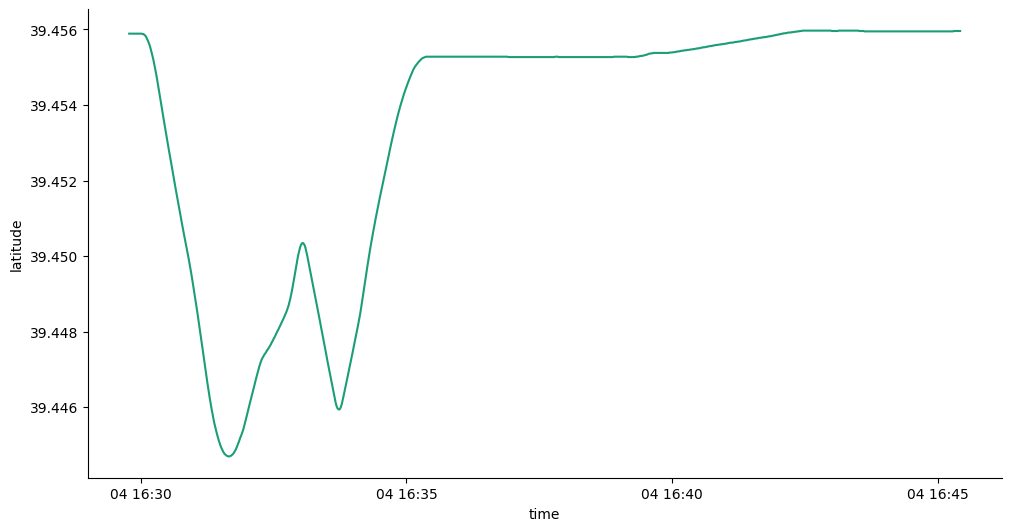

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['time']
  ys = series['latitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time')
_ = plt.ylabel('latitude')

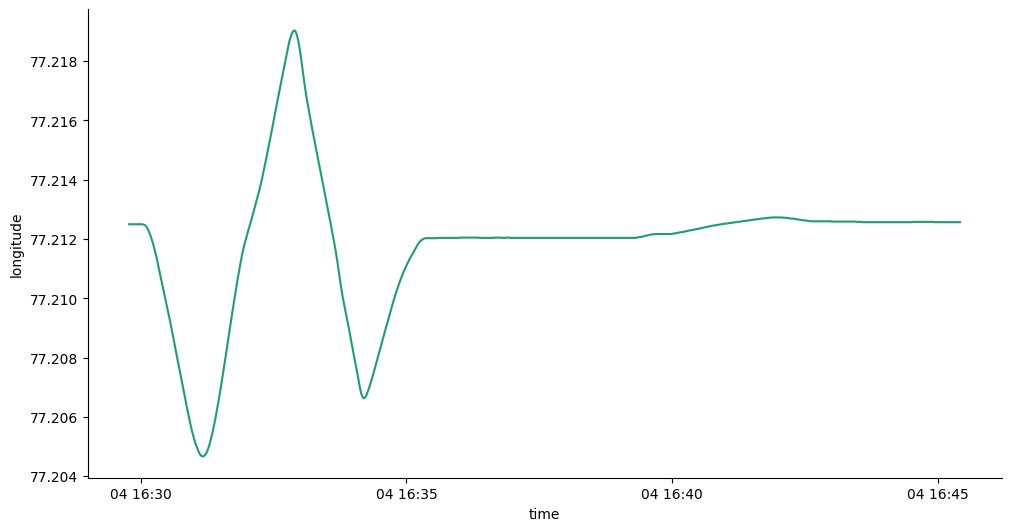

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['time']
  ys = series['longitude']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('time', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('time')
_ = plt.ylabel('longitude')

In [ ]:
!pip install folium

In [ ]:
import folium
from folium import Map, Marker

start_lat = df['latitude'].iloc[0]
start_lon = df['longitude'].iloc[0]

m = folium.Map(location=[start_lat, -start_lon], zoom_start=12)

for _, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], -row['longitude']],
        popup=f"Altitude: {row['altitude']} m\nTime: {row['time']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

m

In [ ]:
times = pd.read_csv('/content/drive/MyDrive/Capstone/Flt-times.1371989.csv')
# times.sample(10, replace=True)

In [ ]:
times.head(10)

Output hidden; open in https://colab.research.google.com to view.